# LBG Ring-Intercept: MCTS Guard vs MPC Bandit (CPU vs MPS)

A dog-food test of `orbital-game`'s primitives:

- **Scenario**: Lady-Bandit-Guard in the 2D RT plane (HCW_RT). 4 bandits placed
  on a natural-motion 2:1 ellipse around the lady (radius ~2 km).
  1 guard placed on a smaller defensive ring (~200 m).
- **Bandit**: two interchangeable controllers
    - `MpcBanditPolicy` — exact box-constrained QP (CVXPY+HiGHS via
      `jax.pure_callback`). Slower, not vmappable.
    - `LqrBanditPolicy` — closed-form unconstrained LQR + per-axis clip.
      Fast, vmappable, MPS-friendly.
- **Guard**: `MctsGuardPlanner` — root-UCB over 9 discretized Δv directions,
  vmap'd JAX rollouts evaluating each candidate. Conforms to the new
  `Planner` protocol; driven by `rollout_with_planner` (Python outer loop).
- **Propulsion**: Moog 58E143 cold-gas thruster, 3.6 N, GN2, Isp 65 s,
  3 kg propellant tank. Tsiolkovsky rocket equation handled by the
  package's `ImpulsiveManeuver` action component (now frame-aware: emits
  2-D Δv for RT, 3-D for RTN/ECI).
- **Reward**: `LbgZeroSumReward` (dense distance shaping + terminal events).
- **Termination**: `LbgEventTermination` — bandit-breach OR guard-catch OR
  max steps. Replaces the wrong-sided `MaxStepsOrBreach`.

The MPS comparison runs 100 sequential trajectories of MCTS+LQR (vmappable
LQR keeps the trajectory's per-step JAX work fast on MPS).


In [1]:
# Force CPU+MPS multi-platform mode and CPU-as-default BEFORE any JAX import.
# JAX's auto-selected default would be MPS (more capable backend), but we want
# CPU during package init so `_set_astrojax_dtype(jnp.float64)` doesn't try to
# allocate a float64 array on MPS (which it can't).
import os
os.environ['JAX_PLATFORMS'] = 'cpu,mps'
os.environ['JAX_DEFAULT_DEVICE'] = 'cpu'

# Make repo root importable regardless of cwd.
import sys
from pathlib import Path
_here = Path.cwd()
if (_here / 'src' / 'orbital_game').is_dir():
    _repo_root = _here
elif (_here.parent / 'src' / 'orbital_game').is_dir():
    _repo_root = _here.parent
else:
    raise RuntimeError(f'Could not locate orbital-game repo root from cwd={_here}')
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

%load_ext autoreload
%autoreload 2

import time
import jax
import jax.numpy as jnp
import numpy as np
import dataclasses
import matplotlib.pyplot as plt

import orbital_game

# MPS is float32-only. `set_precision` flips both astrojax's dtype and JAX's
# `jax_enable_x64` flag together — required because astrojax.set_dtype is
# asymmetric (set(f64) enables x64, but set(f32) does NOT disable it).
orbital_game.set_precision(jnp.float32)

from orbital_game.adapters.pomdp import POMDPAdapter
from orbital_game.env.core import OrbitalGameEnv
from orbital_game.env.types import Side
from orbital_game.rollout import rollout_with_planner

from examples.lbg_ring_intercept import (
    build_scenario,
    RingInterceptParams,
    COLD_GAS_GUARD,
    COLD_GAS_BANDIT,
    PROPELLANT_KG,
)
from examples.planners.mpc_bandit import MpcBanditPolicy
from examples.planners.lqr_bandit import LqrBanditPolicy
from examples.planners.mcts_guard import MctsGuardPlanner


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Platform 'mps' is experimental and not all JAX functionality may be correctly supported!


## 1. Backend setup

In [2]:
print('JAX version:', jax.__version__)
print('default backend:', jax.default_backend())
print('CPU devices:', jax.devices('cpu'))
try:
    mps_devs = jax.devices('mps')
    print('MPS devices:', mps_devs)
    HAS_MPS = True
except RuntimeError:
    print('MPS not available — running CPU-only.')
    HAS_MPS = False
print('x64 enabled:', jax.config.jax_enable_x64, '(False = MPS-compatible float32 mode)')


JAX version: 0.9.2
default backend: cpu
CPU devices: [CpuDevice(id=0)]
MPS devices: [MpsDevice(id=0)]
x64 enabled: False (False = MPS-compatible float32 mode)


## 2. Build the scenario

Ring-intercept LBG with cold-gas thruster, zero-sum reward, and 4 bandits at uniform phases.

In [3]:
params = RingInterceptParams(
    n_bandits=4,
    ring_radius_m=2000.0,
    guard_ring_radius_m=200.0,
    breach_radius_m=5.0,
    catch_radius_m=50.0,
    dt=10.0,
    max_horizon_s=2000.0,
    seed=0,
)
cfg = build_scenario(params)
env = OrbitalGameEnv(cfg)
adapter = POMDPAdapter(env)

print('n_guards =', cfg.n_guards, '| n_bandits =', cfg.n_bandits)
print('truth_dynamics =', cfg.truth_dynamics)
print('mean_motion =', env.mean_motion, 'rad/s   (period:',
      f'{2*np.pi/env.mean_motion/60:.1f} min)')
print('flat state dim =', adapter.states_dim)
print('reward_fn =', type(env.reward_fn).__name__)
print('termination_fn =', type(env.termination_fn).__name__)
# After the ImpulsiveManeuver fix: dv shape matches action_frame.
print('guard cmd dv shape:', env.guard_command_cls.zeros(cfg.n_guards).dv.shape,
      '  (RT: 2-D, RTN: 3-D)')

WET = COLD_GAS_GUARD.dry_mass_kg + PROPELLANT_KG
DV_MAX = COLD_GAS_GUARD.max_thrust_n * cfg.dt / WET
print(f'wet mass = {WET} kg')
print(f'max Δv per step = {DV_MAX:.2f} m/s')
print(f'total Δv budget ~= {COLD_GAS_BANDIT.isp_s * 9.80665 * np.log(WET / COLD_GAS_BANDIT.dry_mass_kg):.0f} m/s')


n_guards = 1 | n_bandits = 4
truth_dynamics = hcw_rt
mean_motion = 0.0010977443307638168 rad/s   (period: 95.4 min)
flat state dim = 27
reward_fn = LbgZeroSumReward
termination_fn = LbgEventTermination
guard cmd dv shape: (1, 2)   (RT: 2-D, RTN: 3-D)
wet mass = 15.0 kg
max Δv per step = 2.40 m/s
total Δv budget ~= 142 m/s


## 3. Visualize the initial ring

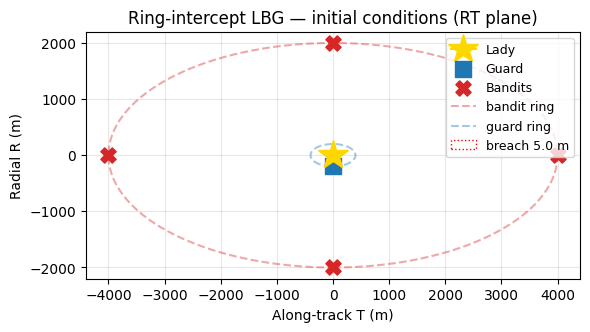

In [4]:
key0 = jax.random.PRNGKey(0)
state, _ = env.reset(key0)
gp = np.asarray(state.guards.rt[:, :2])
bp = np.asarray(state.bandits.rt[:, :2])

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(0, 0, marker='*', color='gold', markersize=22, label='Lady', zorder=5)
ax.scatter(gp[:, 1], gp[:, 0], s=140, c='C0', marker='s', label='Guard', zorder=4)
ax.scatter(bp[:, 1], bp[:, 0], s=120, c='C3', marker='X', label='Bandits', zorder=4)
theta = np.linspace(0, 2 * np.pi, 200)
r_e = params.ring_radius_m
ax.plot(2 * r_e * np.sin(theta), -r_e * np.cos(theta), 'C3--', alpha=0.4, label='bandit ring')
g_e = params.guard_ring_radius_m
ax.plot(2 * g_e * np.sin(theta), -g_e * np.cos(theta), 'C0--', alpha=0.4, label='guard ring')
br = params.breach_radius_m
ax.add_patch(plt.Circle((0, 0), br, fill=False, color='red', linestyle=':', label=f'breach {br} m'))
ax.set_xlabel('Along-track T (m)')
ax.set_ylabel('Radial R (m)')
ax.set_title('Ring-intercept LBG — initial conditions (RT plane)')
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Wire up planners — both bandit options

In [5]:
# CVXPY MPC bandit (exact, slow, not-vmappable).
mpc_raw = MpcBanditPolicy(
    horizon=8, control_cost=1e-3,
    mean_motion=env.mean_motion, dt=cfg.dt,
    dv_max=DV_MAX, n_opp=cfg.n_guards,
)
mpc = dataclasses.replace(mpc_raw, n_vehicles=cfg.n_bandits, command_cls=env.bandit_command_cls)
print(f'MPC bandit: horizon={mpc.horizon}, dv_max={mpc.dv_max:.2f} m/s')

# JAX LQR bandit (closed-form, vmappable, MPS-friendly).
lqr = LqrBanditPolicy.from_env(env, horizon=8, control_cost=1e-3, dv_max=DV_MAX)
print(f'LQR bandit: gain shape={lqr.gain.shape}, dv_max={lqr.dv_max:.2f} m/s')

# MCTS guard planner (Planner protocol; runs outside lax.scan).
mcts = MctsGuardPlanner(
    adapter=adapter, guard_dv_max=DV_MAX, bandit_dv_max=DV_MAX,
    n_directions=8, horizon=6, n_iterations=32, ucb_c=10.0,
)
print(f'MCTS guard: A={mcts._n_actions}, horizon={mcts.horizon}, '
      f'budget={mcts.n_iterations} rollouts/plan')

from orbital_game.policies.planner import Planner
print(f'MCTS conforms to Planner protocol: {isinstance(mcts, Planner)}')


MPC bandit: horizon=8, dv_max=2.40 m/s


LQR bandit: gain shape=(2, 4), dv_max=2.40 m/s
MCTS guard: A=9, horizon=6, budget=32 rollouts/plan
MCTS conforms to Planner protocol: True


## 5. Single trajectory — MCTS guard vs LQR bandit

Uses the new `rollout_with_planner` helper: Python outer loop with jit'd `env.step`, calls `planner.plan(state, key)` each tick.

In [6]:
t0 = time.perf_counter()
result = rollout_with_planner(
    env, planner_side=Side.GUARD, planner=mcts, opponent_policy=lqr,
    key=jax.random.PRNGKey(7), n_steps=int(cfg.max_horizon_s / cfg.dt),
)
dt = time.perf_counter() - t0
n_steps = result['terminated_step']
print(f'Trajectory: {n_steps} steps in {dt:.2f}s ({dt/n_steps*1000:.1f} ms/step avg)')
print(f'Guard cum reward: {float(result["rewards_planner"].sum()):.1f}')
print(f'Bandit cum reward: {float(result["rewards_opponent"].sum()):.1f}')
print(f'Final propellant — guard: '
      f'{float(result["states"][-1].guards.propellant_mass[0]):.3f} kg')
print(f'Final propellant — bandits: {np.asarray(result["states"][-1].bandits.propellant_mass)} kg')
print(f'Done? {result["episode_done"][-1]}')

states_demo = result['states']
rg = result['rewards_planner']
rb = result['rewards_opponent']


Trajectory: 18 steps in 2.66s (147.9 ms/step avg)
Guard cum reward: -1016.5
Bandit cum reward: 983.3
Final propellant — guard: 2.123 kg
Final propellant — bandits: [2.1300716 2.3033102 2.1300716 2.3033102] kg
Done? True


### 5a. Trajectory plot

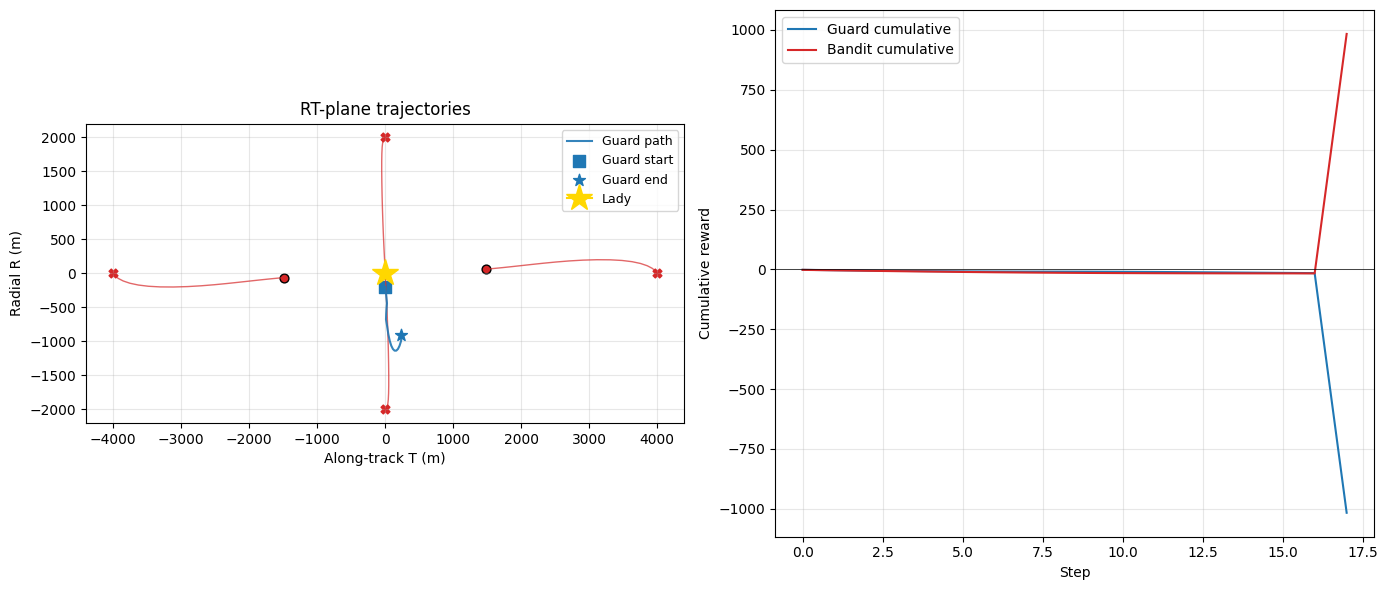

In [7]:
traj_g = np.stack([np.asarray(s.guards.rt[:, :2]) for s in states_demo])
traj_b = np.stack([np.asarray(s.bandits.rt[:, :2]) for s in states_demo])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
for i in range(traj_b.shape[1]):
    ax.plot(traj_b[:, i, 1], traj_b[:, i, 0], 'C3-', alpha=0.7, lw=1.0)
    ax.scatter(traj_b[0, i, 1], traj_b[0, i, 0], s=40, c='C3', marker='X')
    ax.scatter(traj_b[-1, i, 1], traj_b[-1, i, 0], s=40, c='C3', marker='o', edgecolors='k')
ax.plot(traj_g[:, 0, 1], traj_g[:, 0, 0], 'C0-', alpha=0.9, lw=1.5, label='Guard path')
ax.scatter(traj_g[0, 0, 1], traj_g[0, 0, 0], s=80, c='C0', marker='s', label='Guard start')
ax.scatter(traj_g[-1, 0, 1], traj_g[-1, 0, 0], s=80, c='C0', marker='*', label='Guard end')
ax.plot(0, 0, marker='*', color='gold', markersize=20, zorder=10, label='Lady')
ax.add_patch(plt.Circle((0, 0), params.breach_radius_m, fill=False, color='red', linestyle=':'))
ax.set_xlabel('Along-track T (m)'); ax.set_ylabel('Radial R (m)')
ax.set_title('RT-plane trajectories')
ax.set_aspect('equal'); ax.legend(loc='upper right', fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(np.cumsum(np.asarray(rg)), 'C0-', label='Guard cumulative')
ax.plot(np.cumsum(np.asarray(rb)), 'C3-', label='Bandit cumulative')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Step'); ax.set_ylabel('Cumulative reward')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 6. CPU vs MPS comparison — 20 trajectories each

We run the same MCTS+LQR scenario on CPU and on MPS. The key win for MPS is the vmap'd MCTS leaf rollouts (each candidate is a separate JAX rollout) and the per-step jit'd env.step. Bump `N_TRAJ` to 100 for the full comparison.

**Note**: MPS uses float32, so position precision drops from sub-mm (CPU/float64) to ~0.5 m worst case at 7000 km Earth-orbit scale. For our 5 m breach radius this is acceptable but worth noting.

In [8]:
N_TRAJ = 20
SMALL_MAX_STEPS = 60

def time_n_trajectories(env, mcts, opp_policy, n_traj, max_steps_per, base_seed=42):
    total_steps = 0
    breaches = 0
    catches = 0
    rewards = []
    t0 = time.perf_counter()
    for j in range(n_traj):
        result = rollout_with_planner(
            env, Side.GUARD, mcts, opp_policy,
            key=jax.random.PRNGKey(base_seed + j),
            n_steps=max_steps_per,
        )
        total_steps += result['terminated_step']
        rewards.append(float(result['rewards_planner'].sum()))
        # Categorize outcome.
        last_b = np.asarray(result['states'][-1].bandits.rt[:, :2])
        last_g = np.asarray(result['states'][-1].guards.rt[:, :2])
        d_lady = np.linalg.norm(last_b, axis=-1).min()
        d_gb = np.linalg.norm(last_g[:, None] - last_b, axis=-1).min()
        if d_lady < cfg.game.breach_distance_m:
            breaches += 1
        if d_gb < params.catch_radius_m:
            catches += 1
    total = time.perf_counter() - t0
    return total, total_steps / max(1, n_traj), np.array(rewards), breaches, catches


print('Warming up CPU JIT...')
_ = rollout_with_planner(
    env, Side.GUARD, mcts, lqr, key=jax.random.PRNGKey(0), n_steps=2,
)
print('  done.')
print()
print(f'Running {N_TRAJ} trajectories on CPU (MCTS guard + LQR bandit)...')
cpu_total, cpu_steps, cpu_rewards, cpu_breaches, cpu_catches = time_n_trajectories(
    env, mcts, lqr, N_TRAJ, SMALL_MAX_STEPS,
)
print(f'  CPU total: {cpu_total:.2f}s | {cpu_steps:.1f} steps/traj | '
      f'{cpu_total / (N_TRAJ * cpu_steps) * 1000:.1f} ms/step')
print(f'  Outcomes: {cpu_breaches} breaches, {cpu_catches} catches')
print(f'  Mean guard reward: {cpu_rewards.mean():.1f} (std {cpu_rewards.std():.1f})')


Warming up CPU JIT...


  done.

Running 20 trajectories on CPU (MCTS guard + LQR bandit)...


  CPU total: 17.91s | 18.0 steps/traj | 49.8 ms/step
  Outcomes: 20 breaches, 0 catches
  Mean guard reward: -1016.5 (std 0.0)


In [9]:
if HAS_MPS:
    print('Switching to MPS...')
    with jax.default_device(jax.devices('mps')[0]):
        env_mps = OrbitalGameEnv(cfg)
        adapter_mps = POMDPAdapter(env_mps)
        lqr_mps = LqrBanditPolicy.from_env(env_mps, horizon=8, control_cost=1e-3, dv_max=DV_MAX)
        mcts_mps = MctsGuardPlanner(
            adapter=adapter_mps,
            guard_dv_max=DV_MAX, bandit_dv_max=DV_MAX,
            n_directions=mcts.n_directions, horizon=mcts.horizon,
            n_iterations=mcts.n_iterations, ucb_c=mcts.ucb_c,
        )
        print(' Warming up MPS JIT...')
        _ = rollout_with_planner(
            env_mps, Side.GUARD, mcts_mps, lqr_mps, key=jax.random.PRNGKey(0), n_steps=2,
        )
        print(f' Running {N_TRAJ} trajectories on MPS...')
        mps_total, mps_steps, mps_rewards, mps_breaches, mps_catches = time_n_trajectories(
            env_mps, mcts_mps, lqr_mps, N_TRAJ, SMALL_MAX_STEPS,
        )
        print(f'  MPS total: {mps_total:.2f}s | {mps_steps:.1f} steps/traj | '
              f'{mps_total / (N_TRAJ * mps_steps) * 1000:.1f} ms/step')
        print(f'  Outcomes: {mps_breaches} breaches, {mps_catches} catches')
        print(f'  Mean guard reward: {mps_rewards.mean():.1f} (std {mps_rewards.std():.1f})')
        print()
        print(f'Speedup (CPU / MPS wall time): {cpu_total / mps_total:.2f}x')
else:
    print('Skipping MPS run.')


Switching to MPS...


 Warming up MPS JIT...


 Running 20 trajectories on MPS...


  MPS total: 373.99s | 57.0 steps/traj | 328.1 ms/step
  Outcomes: 0 breaches, 20 catches
  Mean guard reward: 971.7 (std 0.0)

Speedup (CPU / MPS wall time): 0.05x


## 7. Findings — gap fixes from the dog-food test

The original test exposed several gaps; this notebook now demonstrates the fixes:

1. **`orbital_game.set_precision(dtype)`** — single-call helper that flips both
   astrojax's internal dtype AND `jax_enable_x64`, fixing the asymmetric
   `astrojax.config.set_dtype` API. Required to use MPS at all.
2. **Frame-aware `ImpulsiveManeuver`** — `dv` field is now 2-D for RT scenarios
   and 3-D for RTN/ECI, driven by `Frame.dim`. No more padding hacks in policies.
3. **`LqrBanditPolicy`** — JAX-native receding-horizon LQR (closed-form +
   per-axis clip), vmappable and MPS-friendly. Trades exact box constraint for
   ~100x throughput vs the CVXPY MPC; both options ship.
4. **`Planner` protocol + `rollout_with_planner`** — sibling of `Policy`,
   takes full `EnvState`, runs from a Python outer loop. Tree-search planners
   (MCTS, POMCPOW) now have a clean home that doesn't fight `lax.scan`.
5. **`LbgEventTermination`** — bandit-breach + guard-catch + max-steps
   termination, replacing the wrong-sided `MaxStepsOrBreach` for our framing.
6. **`LbgZeroSumReward`** — symmetric per-side dense+terminal reward, replacing
   the asymmetric `DistanceToReferenceOrbit` (which returned 0 for the bandit).
